In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.model_selection import train_test_split

#np.random.seed(42)

# 1. Sample X from multivariate Gaussian
n_samples = 1000
n_features = 100
idx = np.arange(n_features)
cov = (0.5 ** np.abs(idx[:, None] - idx[None, :])) # covariance: Cov(i,j) = 2*(0.5)^{abs(i-j)}
L = linalg.cholesky(cov, lower=True)
true_theta = np.random.uniform(-1, 1, (n_features + 1, 1))


# 2. Sample X from clusters


In [67]:
def get_leverage_scores(X_subset, X_full):
    # Calculate leverage of X_full relative to X_subset
    # Formula: diag(X (XtX)^-1 Xt)
    try:
        inv_xtx = np.linalg.inv(X_subset.T @ X_subset + 1e-6 * np.eye(X_subset.shape[1]))
        leverage = np.sum((X_full @ inv_xtx) * X_full, axis=1)
        return leverage
    except np.linalg.LinAlgError:
        return np.random.rand(X_full.shape[0])

def get_influence_scores(X_pool, y_pool, w_current, X_tgt, y_tgt):
    """LESS-style: Alignment between training gradients and target gradient"""
    preds_tgt = X_tgt @ w_current
    error_tgt = (y_tgt - preds_tgt).flatten()
    avg_grad_tgt = -(error_tgt[:, None] * X_tgt).mean(axis=0)
    
    preds_pool = X_pool @ w_current
    error_pool = (y_pool - preds_pool).flatten()
    grads_pool = -(error_pool[:, None] * X_pool)
    return grads_pool @ avg_grad_tgt

from sklearn.cluster import KMeans

def select_prismatic(k, X_pool, y_pool, w_current, cluster_ratio=0.1):
    """
    Prismatic Synthesis using sklearn KMeans.
    Selects k samples by sampling clusters with probability 1/size.
    """
    # 1. Calculate Per-Sample Gradients (Numpy)
    preds = X_pool @ w_current
    grads_pool = -(y_pool - preds) * X_pool
    
    # 2. Determine Number of Clusters
    n_clusters = max(2, int(len(X_pool) * cluster_ratio))
    n_clusters = min(n_clusters, len(X_pool))

    # 3. Perform KMeans Clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
    cluster_labels = kmeans.fit_predict(grads_pool)

    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    weights = 1.0 / counts
    weights_norm = weights / weights.sum()

    sampled_cluster_ids = np.random.choice(unique_labels, size=k, p=weights_norm, replace=True)

    selected_rel_indices = []
    for cid in sampled_cluster_ids:
        in_cluster_indices = np.where(cluster_labels == cid)[0]
        choice = np.random.choice(in_cluster_indices)
        selected_rel_indices.append(choice)
            
    return selected_rel_indices

In [68]:
def train_model(true_theta, X_pool, y_pool, X_tgt, y_tgt, X_test, y_test, strategy='random', nbatch = 10, n_steps = 100, lr=0.01):
    theta = np.random.normal(0, 0.1, size=(n_features + 1, 1))
    mse_history = []
    theta_errs = []
    selected_indices = set()

    for step in range(n_steps):
        mse = np.mean(0.5*(X_test @ theta - y_test)**2)
        mse_history.append(mse.item())
        theta_err = np.linalg.norm(theta-true_theta, ord=1)
        theta_errs.append(theta_err.item())
            
        all_ids = set(range(len(X_pool)))
        remaining_idx = np.array(list(all_ids - selected_indices))
        
        if len(remaining_idx) < nbatch: 
            #print(f"{strategy}: Pool exhausted at step {step} with {len(remaining_idx)}")
            break

        X_r, y_r = X_pool[remaining_idx], y_pool[remaining_idx]

        if strategy == "random":
            rel_indices = np.random.choice(len(remaining_idx), nbatch, replace=False)
        if strategy == 'influence':
            rel_indices = np.argsort(get_influence_scores(X_r, y_r, theta, X_tgt, y_tgt))[-nbatch:]
            # High leverage relative to FULL pool (Quality/Outliers)
            #lev = get_leverage_scores(X_pool, X_pool[remaining_idx])
            #best_new = np.argsort(lev)[-nbatch:]
        elif strategy == 'diversity':
            rel_indices = select_prismatic(nbatch, X_r, y_r, theta)
            # High leverage relative to CURRENT training set (D-Optimality)
            #lev = get_leverage_scores(X_train, X_pool[remaining_idx])
            #best_new = np.argsort(lev)[-nbatch]
        elif strategy == 'div2inf':
            # PROPOSAL: Diversity first, then Influence
            rel_indices = select_prismatic(nbatch, X_r, y_r, theta) if step < n_steps//4 else \
                np.argsort(get_influence_scores(X_r, y_r, theta, X_tgt, y_tgt))[-nbatch:]
        elif strategy == 'inf2div':
            # PROPOSAL: Diversity first, then Influence
            rel_indices = select_prismatic(nbatch, X_r, y_r, theta) if step > n_steps//4 else \
                np.argsort(get_influence_scores(X_r, y_r, theta, X_tgt, y_tgt))[-nbatch:]

        curr_indices = remaining_idx[rel_indices]
        selected_indices.update(curr_indices.tolist())

        # SGD Update
        X_train, y_train = X_pool[curr_indices], y_pool[curr_indices]
        grad = (X_train.T @ (X_train @ theta - y_train)) / nbatch
        theta -= lr * grad
        
    return mse_history, theta_errs

In [69]:
n_runs = 20
strategies = ['random', 'diversity', 'influence', 'div2inf', 'inf2div']
aggregated_mse = {s: [] for s in strategies}
aggregated_theta = {s: [] for s in strategies}

for run in range(n_runs):
    # --- Re-generate Data for each run to ensure robustness ---
    X_raw = np.random.randn(n_samples, n_features) @ L.T
    X_full = np.hstack([np.ones((n_samples, 1)), X_raw])
    y_full = X_full @ true_theta + np.random.normal(0, 0.5, (n_samples, 1)) # 720 180 100
    
    X_combined, X_test, y_combined, y_test = train_test_split(X_full, y_full, test_size = 0.1)
    X_pool, X_tgt, y_pool, y_tgt = train_test_split(X_combined, y_combined, test_size = 0.2)

    for s in strategies:
        mse, theta_err = train_model(true_theta, X_pool, y_pool, X_tgt, y_tgt, X_test, y_test, strategy=s)
        aggregated_mse[s].append(mse)
        aggregated_theta[s].append(theta_err)

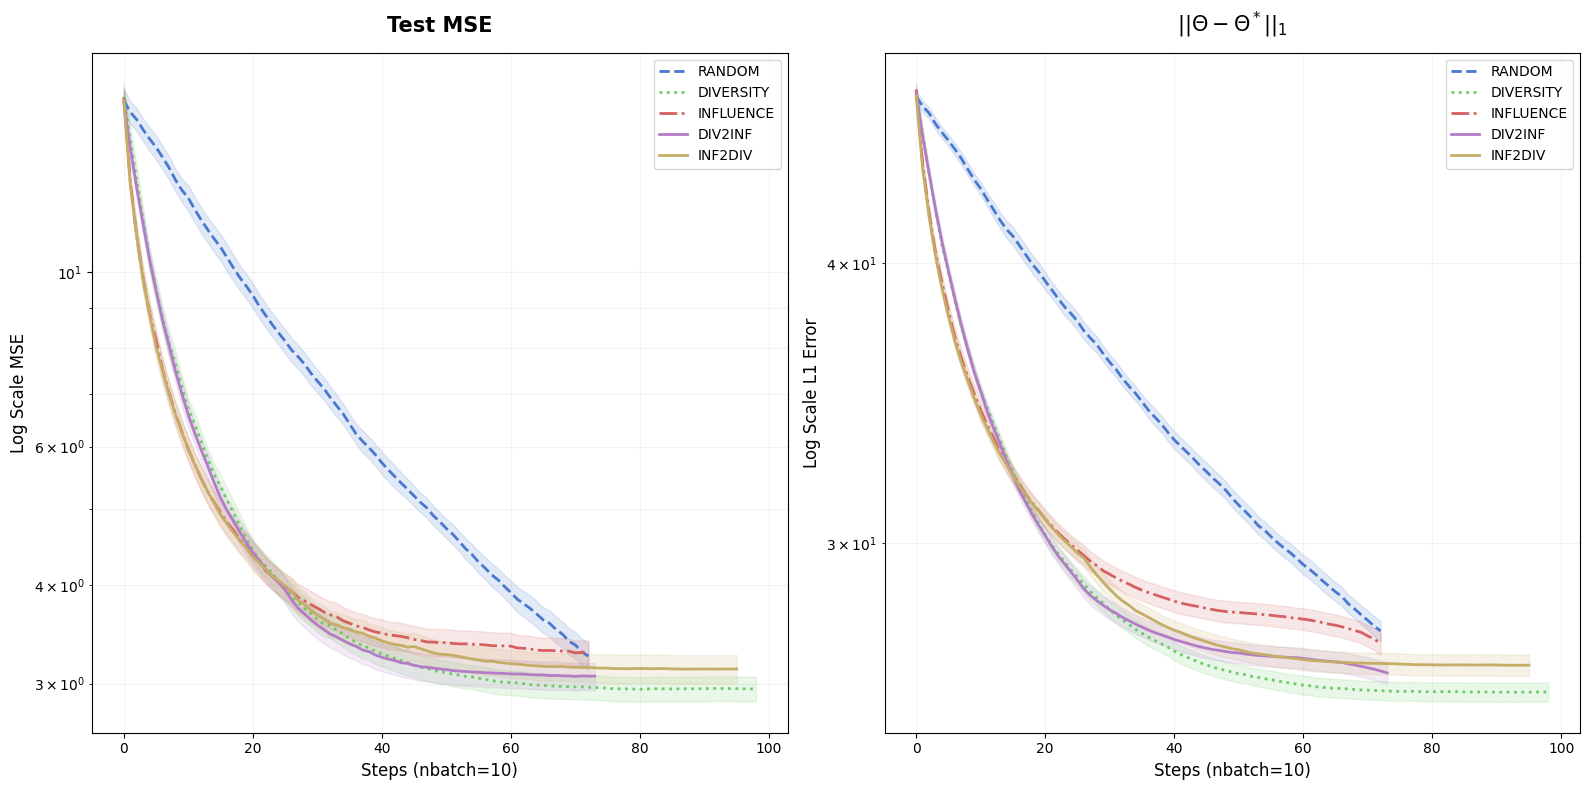

In [70]:
def plot_research_results(mse_results, theta_results, n_runs):
    # Modern style
    plt.style.use('seaborn-v0_8-muted') 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    strategies = list(mse_results.keys())
    line_styles = {
        'random': '--', 
        'diversity': ':', 
        'influence': '-.', 
        'div2inf': '-', 
        'inf2div': '-'
    }

    for label in strategies:
        # --- FIX: Handle inhomogeneous shapes ---
        # Find the minimum length among all runs for this strategy
        min_len_mse = min(len(run) for run in mse_results[label])
        min_len_theta = min(len(run) for run in theta_results[label])
        
        # Truncate all runs to the minimum length so they align perfectly
        mse_list = [run[:min_len_mse] for run in mse_results[label]]
        theta_list = [run[:min_len_theta] for run in theta_results[label]]
        
        # Now convert to numpy arrays safely
        mse_arr = np.array(mse_list)
        theta_arr = np.array(theta_list)
        
        # 1. Process MSE (Functional)
        mse_mean = np.mean(mse_arr, axis=0)
        mse_std = np.std(mse_arr, axis=0) / np.sqrt(n_runs)
        
        # 2. Process Theta (Structural)
        theta_mean = np.mean(theta_arr, axis=0)
        theta_std = np.std(theta_arr, axis=0) / np.sqrt(n_runs)
        
        steps = np.arange(len(mse_mean))
        style = line_styles.get(label, '-')
        # Make the proposed research line (div2inf) pop
        lw = 2 if label == 'div2inf' else 2 

        # --- Plot 1: Test MSE ---
        p1 = ax1.plot(steps, mse_mean, label=label.upper(), 
                      linestyle=style, linewidth=lw)
        ax1.fill_between(steps, mse_mean - mse_std, mse_mean + mse_std, 
                         alpha=0.15, color=p1[0].get_color())
        
        # --- Plot 2: Theta Error (L1) ---
        p2 = ax2.plot(steps, theta_mean, label=label.upper(), 
                      linestyle=style, linewidth=lw)
        ax2.fill_between(steps, theta_mean - theta_std, theta_mean + theta_std, 
                         alpha=0.15, color=p2[0].get_color())

    # --- Refine Left Plot ---
    ax1.set_yscale('log')
    ax1.set_title("Test MSE", fontsize=15, fontweight='bold', pad=15)
    ax1.set_xlabel("Steps (nbatch=10)", fontsize=12)
    ax1.set_ylabel("Log Scale MSE", fontsize=12)
    ax1.grid(True, which="both", ls="-", alpha=0.15)
    ax1.legend(loc='upper right', fontsize=10)

    # --- Refine Right Plot ---
    ax2.set_yscale('log')
    # Updated title for L1 Norm
    ax2.set_title("$||\Theta - \Theta^*||_1$", fontsize=15, fontweight='bold', pad=15)
    ax2.set_xlabel("Steps (nbatch=10)", fontsize=12)
    ax2.set_ylabel("Log Scale L1 Error", fontsize=12)
    ax2.grid(True, which="both", ls="-", alpha=0.15)
    ax2.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

# Run it!
plot_research_results(aggregated_mse, aggregated_theta, n_runs=10)